# Benchmark de TSDNet en GPU

Este notebook evalúa el checkpoint oficial de **TSDNet** sobre CROHME. El protocolo sigue los scripts de `01_seleccion`: calentamiento previo, entrada ya residente en GPU, sincronización CUDA antes y después de cada inferencia, latencia por muestra y pico incremental de VRAM.

También calcula exact match estructural con la misma representación `(nodos, relaciones, padres)` usada por el repositorio original. Los resultados se guardan en `resultados/`.

In [1]:
from collections import OrderedDict
from pathlib import Path
import gc, json, platform, statistics, sys, time, types

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
import torch
import torch.nn as nn
import yaml

def find_project_root():
    candidates = [Path.cwd(), *Path.cwd().parents, Path.cwd() / '..', Path.cwd() / '../..']
    for candidate in candidates:
        candidate = candidate.resolve()
        if (candidate / 'TSDNet').is_dir() and (candidate / 'data' / 'TSDNet').is_dir():
            return candidate
    raise FileNotFoundError('No se encontró la raíz con TSDNet/ y data/TSDNet/.')

ROOT = find_project_root()
TSD_ROOT = ROOT / 'TSDNet'
DATA_ROOT = ROOT / 'data' / 'TSDNet'
RESULTS_DIR = ROOT / 'Cascada' / '01_seleccion' / 'resultados'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
DEVICE = torch.device('cuda:0')
MB = 1024 ** 2
assert torch.cuda.is_available(), 'CUDA no está disponible.'
print('Raíz:', ROOT)
print('GPU:', torch.cuda.get_device_name(0))
print('PyTorch:', torch.__version__, '| CUDA:', torch.version.cuda)

Raíz: C:\Users\novac\Documents\Unidad\Documentos\IPN\Trabajo_terminal\Programas
GPU: NVIDIA GeForce RTX 4050 Laptop GPU
PyTorch: 2.0.1+cu118 | CUDA: 11.8


## Carga compatible del modelo

Se importan directamente el encoder y el decoder. PyTorch Lightning no interviene en la inferencia y se omite para mantener compatibilidad con el entorno moderno de PyTorch/CUDA.

In [2]:
sys.path.insert(0, str(TSD_ROOT))
models_pkg = types.ModuleType('models')
models_pkg.__path__ = [str(TSD_ROOT / 'models')]
sys.modules['models'] = models_pkg
from models.encoder import Encoder
from models.tsdnet import TSDNet

class Vocabulary:
    pad_tok, sos_tok, eos_tok = '<PAD>', '<SOS>', '<EOS>'
    def __init__(self, path, use_sos=True, use_eos=True):
        tokens = [self.pad_tok]
        if use_sos: tokens.append(self.sos_tok)
        if use_eos: tokens.append(self.eos_tok)
        tokens.extend(line.rstrip('\n') for line in Path(path).open(encoding='utf-8'))
        self.itos = dict(enumerate(tokens))
        self.stoi = {token: index for index, token in self.itos.items()}

class InferenceTSDNet(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.encoder = Encoder(cfg['enc_d_in'], cfg['d_model'], cfg['enc_growth_rate'], cfg['enc_block_config'], dropout=cfg['dropout'], in_channels=cfg['enc_in_channels'])
        self.decoder = TSDNet(cfg['d_model'], cfg['node_vocab_size'], cfg['edge_vocab_size'], cfg['node_emb_size'], cfg['edge_emb_size'], cfg['dec_nc'], cfg['dec_np'], cfg['dec_n_head'], cfg['dec_d_ff'], cfg['dropout'], cfg['dec_activation'], cfg['dec_max_num_hops'])
    def forward(self, images, masks, node_vocab, width=1, max_len=200, length_norm=0):
        x, mask, pos_emb = self.encoder(images, masks)
        return self.decoder.beam_search(x, mask, pos_emb, node_vocab.stoi[node_vocab.pad_tok], node_vocab.stoi[node_vocab.sos_tok], node_vocab.stoi[node_vocab.eos_tok], width, max_len, length_norm)

with (TSD_ROOT / 'configs' / 'crohme.yml').open(encoding='utf-8') as handle:
    config = yaml.safe_load(handle)
node_vocab = Vocabulary(DATA_ROOT / 'node_dict.txt')
edge_vocab = Vocabulary(DATA_ROOT / 'edge_dict.txt', use_sos=False, use_eos=False)
model = InferenceTSDNet(config)
checkpoint = TSD_ROOT / 'trained_models' / 'tsdnet_crohme.pt'
model.load_state_dict(torch.load(checkpoint, map_location='cpu', weights_only=True))
model = model.to(DEVICE).eval().requires_grad_(False)
torch.cuda.synchronize()
parameter_count = sum(p.numel() for p in model.parameters())
parameter_bytes = sum(p.numel() * p.element_size() for p in model.parameters())
buffer_bytes = sum(b.numel() * b.element_size() for b in model.buffers())
model_allocated_mib = torch.cuda.memory_allocated() / MB
print(f'Checkpoint: {checkpoint.name}')
print(f'Parámetros: {parameter_count:,} ({parameter_count / 1e6:.3f} M)')
print(f'Pesos + buffers: {(parameter_bytes + buffer_bytes) / MB:.2f} MiB')
print(f'VRAM asignada tras cargar: {model_allocated_mib:.2f} MiB')

c:\Users\novac\Documents\Unidad\Documentos\IPN\Trabajo_terminal\Programas\.venv-hmer-gpu\lib\site-packages\torch\_utils.py:776: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()


Checkpoint: tsdnet_crohme.pt
Parámetros: 11,412,733 (11.413 M)
Pesos + buffers: 43.59 MiB
VRAM asignada tras cargar: 43.75 MiB


In [3]:
def numeric_suffix(value):
    return int(str(value).rsplit('_', 1)[-1])

def read_structural_ground_truth(lg_path):
    objects, relation_by_destination = [], OrderedDict()
    with Path(lg_path).open(encoding='utf-8') as handle:
        for raw_line in handle:
            tokens = raw_line.rstrip('\n').split(', ')
            if raw_line.startswith('O'):
                objects.append((tokens[1], tokens[2]))
            elif raw_line.startswith('R'):
                destination = tokens[2]
                if destination in relation_by_destination and tokens[3] == 'Inside':
                    continue
                relation_by_destination[destination] = (tokens[1], destination, tokens[3])
    sos_id, eos_id = '<SOS>_0', '<EOS>_1024'
    objects.extend([(sos_id, '<SOS>'), (eos_id, '<EOS>')])
    objects.sort(key=lambda item: numeric_suffix(item[0]))
    object_index = {object_id: index for index, (object_id, _) in enumerate(objects)}
    relations = list(relation_by_destination.values())
    relations.extend([(sos_id, objects[1][0], '<PAD>'), (objects[-2][0], eos_id, '<PAD>')])
    relations.sort(key=lambda item: numeric_suffix(item[1]))
    nodes = [node_vocab.stoi[token] for _, token in objects][1:-1]
    edges = [edge_vocab.stoi[token] for _, _, token in relations][1:-1]
    parents = [object_index[source] - 1 for source, _, _ in relations][1:-1]
    return nodes, edges, parents

def prepare_image(image_path):
    array = np.asarray(Image.open(image_path).convert('L'), dtype=np.float32).copy()
    image = torch.from_numpy(array).div_(255).unsqueeze(0).unsqueeze(0).to(DEVICE)
    mask = torch.zeros((1, array.shape[0], array.shape[1]), dtype=torch.bool, device=DEVICE)
    return image, mask, array.shape

def normalize_prediction(raw_output):
    nodes, edges, parents = raw_output[0]
    return list(map(int, nodes[1:-1])), list(map(int, edges[2:-1])), list(map(int, parents[1:-1]))

def structural_exact_match(prediction, ground_truth):
    return all(pred == truth for pred, truth in zip(prediction, ground_truth))

def node_text(indices):
    return ' '.join(node_vocab.itos.get(index, '<UNK>') for index in indices)

## Configuración del benchmark

`MAX_SAMPLES = None` procesa toda la partición. Para una prueba rápida se puede asignar, por ejemplo, `100`. El valor por defecto de la búsqueda (`BEAM_WIDTH = 1`) coincide con `beam_test` del repositorio.

In [4]:
YEAR = '2014'
MAX_SAMPLES = None
WARMUP_RUNS = 3
BEAM_WIDTH = 1
MAX_LEN = 200
LENGTH_NORM = 0
PROGRESS_EVERY = 25

split_dir = DATA_ROOT / f'test{YEAR}'
metadata = pd.read_csv(split_dir / 'metadata.txt', sep='\t')
metadata = metadata[~metadata['latex'].str.contains(r'\sqrt \[', regex=True)].reset_index(drop=True)
if MAX_SAMPLES is not None:
    metadata = metadata.iloc[:MAX_SAMPLES].copy()
print(f'Muestras seleccionadas: {len(metadata)} | partición: CROHME {YEAR}')

Muestras seleccionadas: 986 | partición: CROHME 2014


In [5]:
first_id = str(metadata.iloc[0]['id'])
warm_image, warm_mask, _ = prepare_image(split_dir / 'bmp' / f'{first_id}.bmp')
with torch.inference_mode():
    for _ in range(WARMUP_RUNS):
        warm_output = model(warm_image, warm_mask, node_vocab, BEAM_WIDTH, MAX_LEN, LENGTH_NORM)
        torch.cuda.synchronize()
        del warm_output
del warm_image, warm_mask
gc.collect(); torch.cuda.synchronize()
print(f'Warm-up terminado: {WARMUP_RUNS} ejecuciones.')

Warm-up terminado: 3 ejecuciones.


In [6]:
rows = []
for index, record in metadata.iterrows():
    sample_id = str(record['id'])
    image_path = split_dir / 'bmp' / f'{sample_id}.bmp'
    tree_path = split_dir / 'tree' / f'{sample_id}.lg'
    row = {'index': index + 1, 'sample_id': sample_id, 'image_file': image_path.name, 'ground_truth_latex': record['latex'], 'status': 'ok', 'error': ''}
    try:
        image, mask, (height, width) = prepare_image(image_path)
        ground_truth = read_structural_ground_truth(tree_path)
        gc.collect(); torch.cuda.synchronize()
        baseline = torch.cuda.memory_allocated()
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()
        start = time.perf_counter()
        with torch.inference_mode():
            raw_output = model(image, mask, node_vocab, BEAM_WIDTH, MAX_LEN, LENGTH_NORM)
        torch.cuda.synchronize()
        elapsed_ms = (time.perf_counter() - start) * 1000
        peak = torch.cuda.max_memory_allocated()
        prediction = normalize_prediction(raw_output)
        row.update({'height': height, 'width': width, 'node_count': len(ground_truth[0]), 'prediction_nodes': node_text(prediction[0]), 'correct': int(structural_exact_match(prediction, ground_truth)), 'time_ms': elapsed_ms, 'base_mib': baseline / MB, 'peak_total_mib': peak / MB, 'peak_increment_mib': (peak - baseline) / MB})
        del raw_output, prediction, ground_truth, image, mask
    except Exception as exc:
        row.update({'status': 'error', 'error': f'{type(exc).__name__}: {exc}', 'correct': np.nan, 'time_ms': np.nan, 'peak_increment_mib': np.nan})
    rows.append(row)
    if (index + 1) % PROGRESS_EVERY == 0 or index + 1 == len(metadata):
        valid = [r for r in rows if r['status'] == 'ok']
        mean_ms = np.mean([r['time_ms'] for r in valid]) if valid else float('nan')
        print(f'{index + 1:4d}/{len(metadata)} | válidas={len(valid):4d} | latencia media={mean_ms:.2f} ms')
    gc.collect()


  25/986 | válidas=  25 | latencia media=311.20 ms
  50/986 | válidas=  50 | latencia media=293.32 ms
  75/986 | válidas=  75 | latencia media=275.93 ms
 100/986 | válidas= 100 | latencia media=273.73 ms
 125/986 | válidas= 125 | latencia media=271.41 ms
 150/986 | válidas= 150 | latencia media=267.39 ms
 175/986 | válidas= 175 | latencia media=266.15 ms
 200/986 | válidas= 200 | latencia media=264.81 ms
 225/986 | válidas= 225 | latencia media=262.19 ms
 250/986 | válidas= 250 | latencia media=262.05 ms
 275/986 | válidas= 275 | latencia media=260.35 ms
 300/986 | válidas= 300 | latencia media=256.46 ms
 325/986 | válidas= 325 | latencia media=254.48 ms
 350/986 | válidas= 350 | latencia media=267.85 ms
 375/986 | válidas= 375 | latencia media=268.58 ms
 400/986 | válidas= 400 | latencia media=266.25 ms
 425/986 | válidas= 425 | latencia media=265.04 ms
 450/986 | válidas= 450 | latencia media=264.10 ms
 475/986 | válidas= 475 | latencia media=259.86 ms
 500/986 | válidas= 500 | laten

In [7]:
results = pd.DataFrame(rows)
valid = results[results['status'] == 'ok'].copy()
latencies = valid['time_ms'].to_numpy()
free_bytes, total_bytes = torch.cuda.mem_get_info()
summary = {
    'model': 'TSDNet', 'dataset': f'CROHME {YEAR}', 'samples_requested': int(len(metadata)),
    'samples_valid': int(len(valid)), 'errors': int((results['status'] != 'ok').sum()),
    'exact_match_percent': float(valid['correct'].mean() * 100),
    'latency_mean_ms': float(np.mean(latencies)), 'latency_median_ms': float(np.median(latencies)),
    'latency_p95_ms': float(np.percentile(latencies, 95)), 'latency_min_ms': float(np.min(latencies)), 'latency_max_ms': float(np.max(latencies)),
    'total_inference_seconds': float(np.sum(latencies) / 1000), 'total_inference_minutes': float(np.sum(latencies) / 60000),
    'parameters': int(parameter_count), 'parameters_millions': parameter_count / 1e6,
    'weights_buffers_mib': (parameter_bytes + buffer_bytes) / MB, 'model_allocated_mib': model_allocated_mib,
    'max_peak_total_mib': float(valid['peak_total_mib'].max()), 'max_peak_increment_mib': float(valid['peak_increment_mib'].max()),
    'gpu': torch.cuda.get_device_name(0), 'gpu_total_mib': total_bytes / MB,
    'python': platform.python_version(), 'pytorch': torch.__version__, 'cuda': torch.version.cuda,
    'beam_width': BEAM_WIDTH, 'max_len': MAX_LEN, 'warmup_runs': WARMUP_RUNS,
    'timing_scope': 'Inferencia GPU; excluye lectura y preprocesamiento CPU.'
}
csv_path = RESULTS_DIR / f'benchmark_tsdnet_crohme_{YEAR}.csv'
json_path = RESULTS_DIR / f'resumen_tsdnet_crohme_{YEAR}.json'
results.to_csv(csv_path, index=False, encoding='utf-8')
json_path.write_text(json.dumps(summary, ensure_ascii=False, indent=2), encoding='utf-8')
display(pd.DataFrame([summary]).T.rename(columns={0: 'valor'}))
print('CSV:', csv_path)
print('Resumen:', json_path)

,valor
model,TSDNet
dataset,CROHME 2014
samples_requested,986
samples_valid,986
errors,0
exact_match_percent,56.186613
latency_mean_ms,248.80245
latency_median_ms,221.9817
latency_p95_ms,476.4828
latency_min_ms,46.7975


CSV: C:\Users\novac\Documents\Unidad\Documentos\IPN\Trabajo_terminal\Programas\Cascada\01_seleccion\resultados\benchmark_tsdnet_crohme_2014.csv
Resumen: C:\Users\novac\Documents\Unidad\Documentos\IPN\Trabajo_terminal\Programas\Cascada\01_seleccion\resultados\resumen_tsdnet_crohme_2014.json


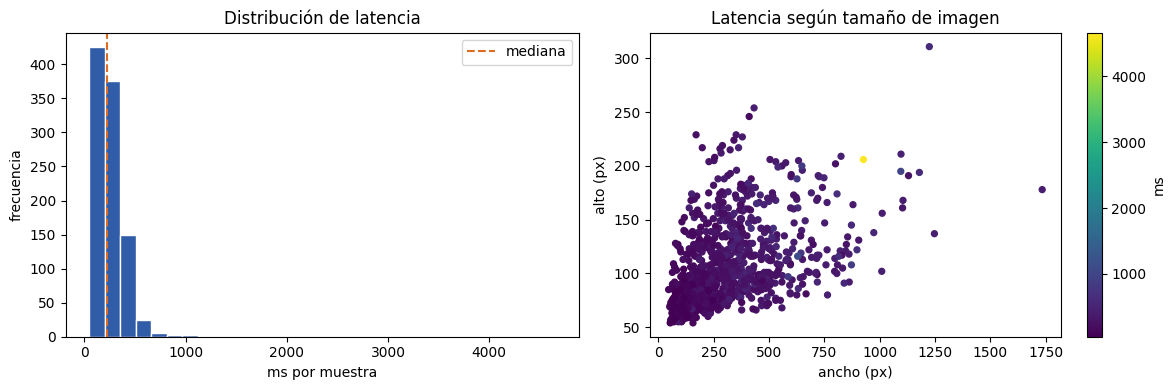

Gráfica: C:\Users\novac\Documents\Unidad\Documentos\IPN\Trabajo_terminal\Programas\Cascada\01_seleccion\resultados\benchmark_tsdnet_crohme_2014.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(valid['time_ms'], bins=30, color='#315da8', edgecolor='white')
axes[0].axvline(summary['latency_median_ms'], color='#dd6b20', linestyle='--', label='mediana')
axes[0].set(title='Distribución de latencia', xlabel='ms por muestra', ylabel='frecuencia'); axes[0].legend()
scatter = axes[1].scatter(valid['width'], valid['height'], c=valid['time_ms'], cmap='viridis', s=18)
axes[1].set(title='Latencia según tamaño de imagen', xlabel='ancho (px)', ylabel='alto (px)')
fig.colorbar(scatter, ax=axes[1], label='ms')
fig.tight_layout()
plot_path = RESULTS_DIR / f'benchmark_tsdnet_crohme_{YEAR}.png'
fig.savefig(plot_path, dpi=160, bbox_inches='tight')
plt.show()
print('Gráfica:', plot_path)

## Lectura de los resultados

- **Exact match** exige que nodos, relaciones y padres sean idénticos al árbol objetivo.
- **Latencia** y **tiempo total de inferencia** miden únicamente inferencia, con la entrada ya copiada a GPU. En esta ejecución, el acumulado fue **331.15 s (5.52 min)**.
- **Pico incremental** resta la memoria asignada justo antes de inferir; por tanto, no confunde los pesos residentes con los tensores temporales.
- Para comparar con otros modelos deben conservarse la misma GPU, partición, calentamiento y alcance temporal.